### **Concatenando Título e Conteúdo**

Este notebook tem a finalidade de concatenar o campo de título e conteúdo do post para processos posteriores

---

In [1]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"../data/raw/expansao/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)


df = pd.DataFrame(rows)

print(f"Arquivos com erro: {len(erros)}")
print(f"Quantidade de subreddits únicos: {df['subreddit'].nunique()}")
print(f"Quantidade de autores únicos: {df['author'].nunique()}")
print(f"Quantidade de posts carregados: {len(df)}")

Arquivos com erro: 0
Quantidade de subreddits únicos: 7372
Quantidade de autores únicos: 1202164
Quantidade de posts carregados: 2227113


In [3]:
df.head()

,id,title,selftext,author,subreddit,score,timestamp,num_comments,url,is_self,over_18,removed_by_category,lang,text,depth
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,NaN,RoyalChris,popculture,107449,2025-03-04T17:20:21+00:00,3736,https://reddit.com/r/popculture/comments/1j3g0...,False,False,NaN,en,Trudeau - ''I want to speak first directly to ...,0
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,S,wyokiddo,popculture,57062,2025-03-17T15:26:59+00:00,2743,https://reddit.com/r/popculture/comments/1jdfb...,False,False,NaN,en,Kim Kardashian endorses Nazi Elon Musk’s cyber...,0
2,1k7jcux,Candace Owens saying she no longer supports Do...,NaN,skyisscary,popculture,27509,2025-04-25T12:10:47+00:00,5419,https://reddit.com/r/popculture/comments/1k7jc...,False,False,NaN,en,Candace Owens saying she no longer supports Do...,0
3,1ilwij6,Kendrick Lamar called out for no white perform...,NaN,IrishStarUS,popculture,23908,2025-02-10T03:13:42+00:00,2525,https://reddit.com/r/popculture/comments/1ilwi...,False,False,NaN,en,Kendrick Lamar called out for no white perform...,0
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",NaN,RoyalChris,popculture,23502,2025-03-20T21:17:23+00:00,1152,https://reddit.com/r/popculture/comments/1jfzx...,False,False,NaN,en,"Elon Musk's daughter, Vivian Wilson, stars in ...",0


In [4]:
print(f"Número de nulos no título: {df['title'].isnull().sum()}")
print(f"Número de nulos no conteúdo: {df['selftext'].isnull().sum()}")

Número de nulos no título: 0
Número de nulos no conteúdo: 1827562


In [5]:
df['title'] = df['title'].fillna('')
df['selftext'] = df['selftext'].fillna('')

df['text'] = df.apply(lambda x: f"{x['title']}. {x['selftext']}" if x['selftext'] != '' else x['title'], axis=1)

df['text'] = df['text'].str.strip()

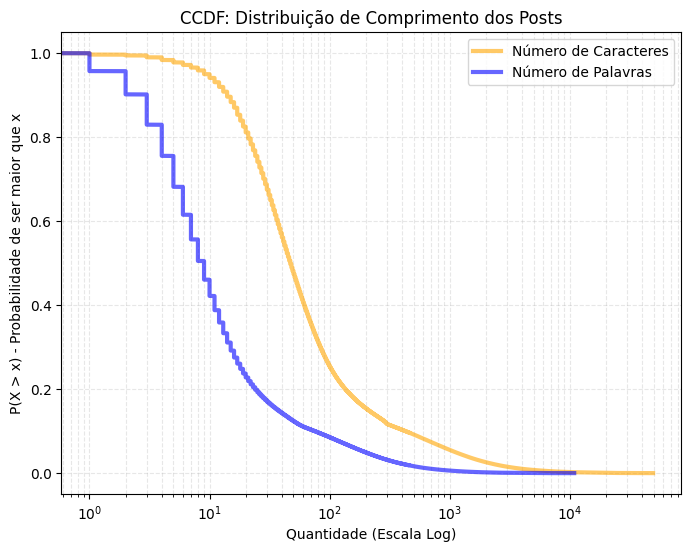

Média: 262.32 chars vs 45.80 palavras
Mediana: 47.00 chars vs 9.00 palavras


In [6]:
# 1. Preparar os dados
text_lengths = df['text'].str.len()
text_num_words = df['text'].apply(lambda t: len(t.split()) if isinstance(t, str) else 0)

# 2. Calcular CCDF para Caracteres
sorted_chars = np.sort(text_lengths)
ccdf_chars = 1.0 - np.arange(len(sorted_chars)) / float(len(sorted_chars))

# 3. Calcular CCDF para Palavras (Lógica idêntica)
sorted_words = np.sort(text_num_words)
ccdf_words = 1.0 - np.arange(len(sorted_words)) / float(len(sorted_words))

# 4. Plotar
plt.figure(figsize=(8, 6))

# Linha de Caracteres
plt.plot(sorted_chars, ccdf_chars, label='Número de Caracteres', color='orange', linewidth=3, alpha=0.6)

# Linha de Palavras
plt.plot(sorted_words, ccdf_words, label='Número de Palavras', color='blue', linewidth=3, alpha=0.6)

plt.title('CCDF: Distribuição de Comprimento dos Posts')
plt.xlabel('Quantidade (Escala Log)')
plt.ylabel('P(X > x) - Probabilidade de ser maior que x')

# Escala logarítmica é essencial para ver ambas as métricas juntas
plt.xscale('log')

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()

plt.show()

# 5. Estatísticas de comparação
print(f"Média: {text_lengths.mean():.2f} chars vs {text_num_words.mean():.2f} palavras")
print(f"Mediana: {text_lengths.median():.2f} chars vs {text_num_words.median():.2f} palavras")

In [7]:
text_map = df.set_index('id')['text'].to_dict()

for depth in range(3 + 1):
    dir_ = f"../data/raw/expansao/{depth}/subreddits"
    if not os.path.exists(dir_): continue
    
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                
                for post in posts:
                    post["text"] = text_map.get(post["id"], "")
                
                with open(path, "w", encoding="utf-8") as f:
                    json.dump(posts, f, indent=4, ensure_ascii=False)
                    
            except Exception as e:
                print(f"Erro ao salvar {path}: {e}")

In [6]:
df[['id','text','subreddit']].to_csv("../data/processed/concatenated_title_selftext.csv", index=False)